# 범주형 자료분석
• 데이터 분석 포인트

#### 적합도 검정

-과거의 이론적 데이터(비율)가 현재의 실제 관찰 데이터를 설명하는 데 잘 적합하는가?

*  H0: 과거 기록에 따라 펭귄 종의 비율은 Adelie 40%, Chinstrap 20%, Gentoo 40% 이다.

* H1: H0가 아니다.

#### 독립성 검정

– 객실 등급이 생존 비율을 예측하는 데 도움이 되는가?

* H0: 객실 등급과 생존 여부는 독립이다. (객실 등급은 생존율을 예측하는 데 아무런 도움을
주지 못한다.)

* H1: 객실 등급과 생존 여부는 독립이 아니다. (객실 등급이라는 정보는 생존율을 예측하는
데 큰 도움을 준다.)

#### 동질성 검정

– 낮 시간의 남녀 비율과 밤 시간의 남녀 비율은 비슷한가?

* H0: 낮 시간의 남녀 비율과 밤 시간의 남녀 비율은 비슷하다.

* H1: 낮 시간의 남녀 비율과 밤 시간의 남녀 비율은 다르다.

적합도 검정 결과 : p-value=0.24991
-> [귀무가설 채택] 과거 이론 비율이 현재 데이터를 잘 설명합니다.


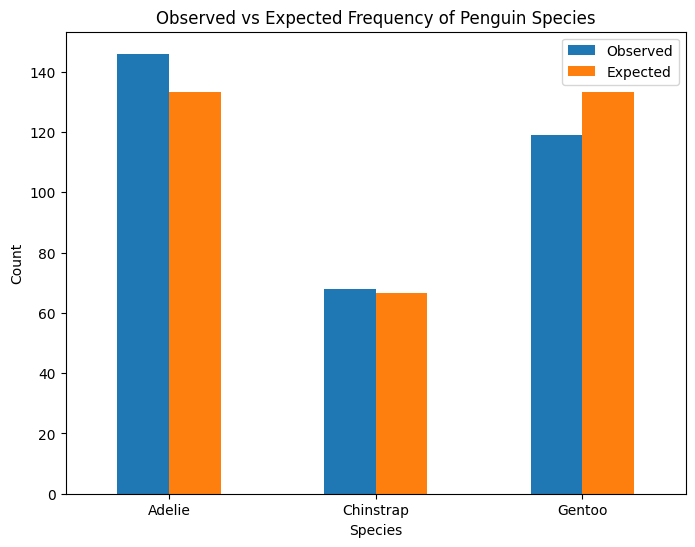

In [39]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 적합도 검정 : 종별 빈도가 과거 이론 비율과 일치하는가?
#과거 비율 -> Adelie 40%, Chinstrap 20%, Gentoo 40%
penguins = sns.load_dataset('penguins').dropna()
observed = penguins['species'].value_counts().sort_index() # 관측 빈도
n = observed.sum() # 전체 표본 수
expected = [n * r for r in [0.4, 0.2, 0.4]] # 이론 비율에 따른 기대 빈도

# 카이제곱 적합도 검정
chi_gof, p_gof = stats.chisquare(f_obs=observed, f_exp=expected)
print(f'적합도 검정 결과 : p-value={p_gof:.5f}')
if p_gof < 0.05:
    print('-> [귀무가설 기각] 현재 종별 비율은 과거 이론 비율과 다릅니다.')
else:
    print('-> [귀무가설 채택] 과거 이론 비율이 현재 데이터를 잘 설명합니다.')

# 관측 빈도 vs 기대 빈도 비교 시각화
compare = pd.DataFrame({'Observed': observed.values, 'Expected': expected},
index=observed.index)
compare.plot(kind='bar', figsize=(8, 6), rot=0)
plt.title('Observed vs Expected Frequency of Penguin Species')
plt.xlabel('Species'); plt.ylabel('Count')
plt.show()

[ 적합도 검정]

· 분석 포인트 : 과거의 이론적 비율이 현재의 실제 관찰 데이터를 잘 설명하는가?

적합도 검정 결과 p-value는 약 0.250으로 유의수준 0.05보다 크다. **따라서 귀무가설을 기각하지
못한다**
즉 현재 수집된 데이터의 종별 빈도는 과거 이론적 비율과 통계적으로 다르다고 볼 수 없으며,
**과거의 이론적 비율이 현재 실제 데이터를 설명하기에 적합하다.**
관측 빈도와 기대 빈도를 비교한
막대그래프에서도 두 막대의 높이가 **종별로 큰 차이 없이 비슷함을** 확인할 수 있다.


독립성 검정 결과 : p-value=4.54925e-23
-> [귀무가설 기각] 객실 등급과 생존 여부는 독립이 아닙니다(종속).


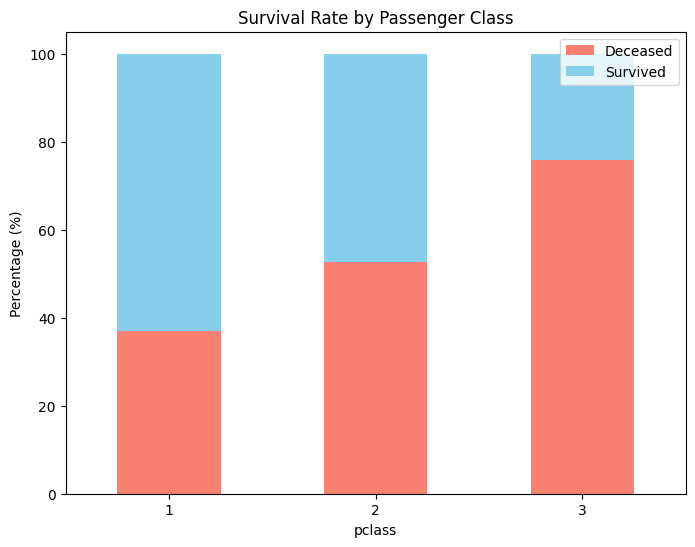

In [40]:
#독립성 검정 : 객실 등급과 생존 여부는 독립인가?
titanic = sns.load_dataset('titanic')
cont_table = pd.crosstab(titanic['pclass'], titanic['survived'])

#교차표
chi_ind, p_ind, dof_ind, exp_ind = stats.chi2_contingency(cont_table)
print(f'독립성 검정 결과 : p-value={p_ind:.5e}')
if p_ind < 0.05:
    print('-> [귀무가설 기각] 객실 등급과 생존 여부는 독립이 아닙니다(종속).')
else:
    print('-> [귀무가설 채택] 객실 등급과 생존 여부는 독립입니다.')

# 객실 등급별 생존율(%) 시각화 (100% 누적 막대)
surv_pct = pd.crosstab(titanic['pclass'], titanic['survived'],
normalize='index') * 100
surv_pct.plot(kind='bar', stacked=True, figsize=(8, 6), rot=0,
color=['salmon', 'skyblue'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('pclass'); plt.ylabel('Percentage (%)')
plt.legend(['Deceased', 'Survived'])
plt.show()

[독립성 검정]

· 분석 포인트 : 객실 등급이 생존 여부를 예측하는 데 도움이 되는가?

독립성 검정 결과 p-value는 유의수준 0.05보다 극단적으로 작다.
따라서 **"객실 등급과 생존 여부는
독립"이라는 귀무가설을 기각한다**. 즉 두 변수는 **서로 독립이 아니며**, **객실 등급은 생존 여부를
예측하는 데 큰 도움** 을 준다.
등급별 생존율 그래프에서

1등급의 생존율이 약 63%로 가장 높고,

2등급(약 47%),

3등급(약 24%)으로 갈수록 생존율이 낮아져

객실 등급이 높을수록 생존 확률이
높았음을 알 수 있다.


동질성 검정 결과 : p-value=0.00224
-> [귀무가설 기각] 점심/저녁의 성별 구성 비율은 동질하지 않습니다.


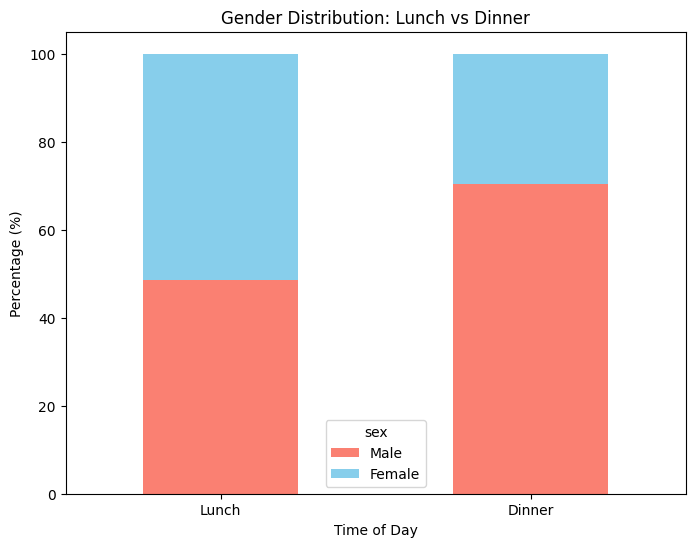

In [42]:
#동질성 검정 : 점심/저녁 시간대별 성별 구성비가 동일한가?
tips = sns.load_dataset('tips')
homo_table = pd.crosstab(tips['sex'], tips['time'])
chi_homo, p_homo, dof_homo, exp_homo = stats.chi2_contingency(homo_table)
print(f'동질성 검정 결과 : p-value={p_homo:.5f}')
if p_homo < 0.05:
    print('-> [귀무가설 기각] 점심/저녁의 성별 구성 비율은 동질하지 않습니다.')
else:
    print('-> [귀무가설 채택] 점심/저녁의 성별 구성 비율은 동질합니다.')

# 시간대별 성별 구성비(%) 시각화 (100% 누적 막대)
gender_pct = pd.crosstab(tips['time'], tips['sex'],
normalize='index') * 100
gender_pct.plot(kind='bar', stacked=True, figsize=(8, 6), rot=0,
color=['salmon', 'skyblue'])
plt.title('Gender Distribution: Lunch vs Dinner')
plt.xlabel('Time of Day'); plt.ylabel('Percentage (%)')
plt.show()

[동질성 검정]

· 분석 포인트 : 점심 시간대와 저녁 시간대의 남녀 구성비가 비슷한가?

동질성 검정 결과 p-value는 약 0.00224로 유의수준 0.05보다 작다.

따라서 **점심과 저녁 시간대의
성별 구성 비율이 같다는 귀무가설을 기각한다.**

즉 두 시간대의 남녀 구성 비율은 동질하지 않으며통계적으로 유의미한 차이가 있다.

교차표를 보면 점심에는 남성 33명·여성 35명으로 성비가 거의
비슷하지만,
저녁에는 남성 124명·여성 52명으로 남성 비율(약 70%)이 크게 높아져

**시간대에 따라
방문 고객의 성별 구성이 달라짐을 확인할 수 있다.**